# Physical Variables Reconstruction — Monte Carlo Paths

Stage 3, step 2. Turns the scenario-agnostic copula innovations into the three
physical variables the revenue index is built from, once per penetration
scenario.

## Objective
Propagate `(eps_CR, eps_KT, eps_temp)` through the fitted marginal dynamics to
produce daily paths of temperature `T_sim`, irradiance `GHI_sim` and capture
rate `CR_sim` over 2026-2050, for each of the three solar-penetration
trajectories.

`T_sim` and `GHI_sim` are **shared** across all three scenarios: penetration
enters only through the capture rate's deterministic mean `mu_CR`. Reusing one
draw of the shared variables is what makes the scenario comparison a
common-random-numbers experiment, in which the difference between two scenarios
is the assumption and not Monte Carlo noise.

SSP **temperature** scenarios are not applied here. They are additive deltas on
`T_sim` and are applied downstream in `04_revenue_index_scenarios.ipynb`, so
this notebook writes three files rather than nine.

## Pipeline Position

| Inputs | This notebook | Outputs |
|---|---|---|
| `Data/Simulated/mc_innovations.parquet` | AR(2) for temperature, ARMA(2,1) + logit inversion for clearness, SARIMA x GARCH for capture rate | `Data/Simulated/mc_physical_variables_current_trend.parquet` |
| `Code/Models/**` fitted parameters | | `..._pniec.parquet` |
| `Data/Cleaned/df_penetration_scenarios.parquet` | | `..._entso_e.parquet` |
| `Data/Modelled/df_*_modelled.parquet` (state initialisation) | | |

## Decision Log

| # | Decision | Alternatives | Rationale | Impact |
|---|---|---|---|---|
| D1 | `N_SIM_USE = 5000` — every path in the innovations file | 1,000 paths | Part II of the hedge notebook estimates equilibrium covariances on a `max(.,0)` payoff, a right-skewed variable whose sample covariance converges slowly. At 1,000 paths the bootstrap standard error of the risk premium was EUR 1.44 per lot against a mean of 4.37, so year-to-year scatter was barely larger than the sampling error and individual years could not be compared | Five times the paths cuts that standard error by about 2.2x. Steps 3 and 4 are vectorised over paths to keep it tractable |
| D2 | Recursions vectorised over paths, looping only over time | Loop over both paths and time | Each recursion is sequential in time but independent across paths, so the inner axis can be an `(N_SIM,)` vector. The arithmetic is identical | A pure-Python double loop at this size is 45.6M iterations per variable; the vectorised form is minutes rather than hours |
| D3 | Solar seasonal mean keyed on **calendar day-of-year** | Absolute day index since the start of the record | `model_meta.json["seasonal"]["basis"]` records that the coefficients were fitted on day-of-year. An absolute index drifts one day per leap year | An absolute index would desynchronise the simulated seasonal phase from the fitted one |
| D4 | The innovations file is read as a **row prefix**, its sim-major order asserted rather than re-sorted | `sort_values(["sim_id", "date"])` on load | The innovations notebook writes contiguous blocks of increasing `sim_id`, each carrying the calendar in identical order, so the file is already in the required order | The sort duplicated a roughly 1.3 GB frame to no effect. The ordering it implicitly relied on is now a stated precondition that fails loudly |
| D5 | Model orders asserted against the loaded coefficient arrays | Trust the hardcoded indices | The recursions index coefficients positionally (`ar_temp[0]`, `ar_temp[1]`) while loading them dynamically. The temperature model moved from AR(1) to AR(2) during this work | Without the assert, a future move to AR(3) would silently drop the third coefficient and understate persistence |
| D6 | Working arrays allocated float32 | float64, cast to float32 only at write time | The stored output is float32 either way, and the modelling error is orders of magnitude larger than float32 resolution | Halves a roughly 3.3 GB peak across the three shared arrays |
| D7 | Streamed parquet writes, one row group per block of 200 paths, with calendar columns **tiled** rather than merged | Build the full frame then write once; left-merge the calendar on `date` | Each block of `N_DAYS` rows carries `dates_sim` in identical order for every path, so tiling is exactly the merge without the 45.6M-element join indexers | Peak memory is one block rather than a full 45.6M-row frame per scenario |

## Setup

In [1]:
import gc
import json
import pickle
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyarrow as pa
import pyarrow.parquet as pq
from scipy import stats
from scipy.stats import t as t_dist, norm
from statsmodels.tsa.arima.model import ARIMAResults

sys.path.append(str(Path("..").resolve()))
from model_utils import find_project_root

warnings.filterwarnings("ignore")

In [2]:
# -- paths ---------------------------------------------------------------------
ROOT          = find_project_root()
data_modelled = ROOT / "Data" / "Modelled"
data_sim      = ROOT / "Data" / "Simulated"
data_cleaned  = ROOT / "Data" / "Cleaned"
models_path   = ROOT / "Code" / "Models"
copula_path   = models_path / "Copula"
output_path   = data_sim
output_path.mkdir(parents=True, exist_ok=True)

In [3]:
# -- simulation constants ------------------------------------------------------
START_DATE = "2026-01-01"
END_DATE   = "2050-12-31"
L_FIXED    = 0.2        # CR trend floor (exponential-decay asymptote).
                        # Must match cr_ar_params.pkl -- asserted below.

# penetration scenario column names in df_penetration_scenarios.parquet
PEN_SCENARIOS = {
    "current_trend": "pen_current_trend",   # 30% by 2050
    "pniec":         "pen_pniec",           # 45% by 2050
    "entso_e":       "pen_entso_e",         # 60% by 2050
}
PEN_LABELS = {
    "current_trend": "Current Trend (30%)",
    "pniec":         "PNIEC 2024 (45%)",
    "entso_e":       "ENTSO-E DE (60%)",
}

print("-- Configuration -----------------------------------------------")
print(f"  Horizon      : {START_DATE} -> {END_DATE}")
print(f"  L_FIXED CR   : {L_FIXED}")
print(f"  Pen scenarios: {list(PEN_SCENARIOS.keys())}")
print(f"  data_sim     : {data_sim}")

-- Configuration -----------------------------------------------
  Horizon      : 2026-01-01 -> 2050-12-31
  L_FIXED CR   : 0.2
  Pen scenarios: ['current_trend', 'pniec', 'entso_e']
  data_sim     : C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Data\Simulated


### Load parameters and innovations

In [4]:
print(f"\n── Step 1: Load parameters and innovations ──────────────────────")

# ── 1.1 copula / marginal parameters ─────────────────────────────────────────
with open(copula_path / "copula_params.pkl", "rb") as f:
    copula_params = pickle.load(f)
nu_copula = int(copula_params["nu"])
print(f"  Copula       : t(ν={nu_copula})")

with open(copula_path / "marginal_params.pkl", "rb") as f:
    marginal_params = pickle.load(f)
sigma_kt   = float(marginal_params["sigma_kt"])
nu_temp    = float(marginal_params["nu_temp"])
scale_temp = float(marginal_params["scale_temp"])
sigma_temp = float(marginal_params["sigma_temp"])
# eps_kt is consumed RAW below — sigma_kt is not applied anywhere in this
# notebook. The KT margin is a per-calendar-month 2-component Gaussian mixture,
# already inverted in the innovations notebook; sigma_kt survives only as a
# legacy key in marginal_params.pkl.
print(f"  KT marginal  : GMM-2 per calendar month "
      f"(inverted upstream; legacy σ={sigma_kt:.5f} unused)")
print(f"  Temp marginal: t(ν={nu_temp:.2f})  scale={scale_temp:.5f}")

# ── 1.2 CR model parameters ───────────────────────────────────────────────────
with open(models_path / "Capture rate" / "cr_ar_params.pkl", "rb") as f:
    cr_params = pickle.load(f)

phi_s        = float(cr_params["phi_s"])
Phi_s        = float(cr_params["Phi_s"])
theta_q      = float(cr_params["theta_q"])
omega_g      = float(cr_params["garch_omega"])
alpha_g      = float(cr_params["garch_alpha"])
beta_g       = float(cr_params["garch_beta"])
nu_g         = float(cr_params["nu_g"])
eta_g        = float(cr_params["eta_g"])   # skewness parameter
L_FIXED_cr   = float(cr_params["L_FIXED"])
U_FIXED_cr   = float(cr_params["U_FIXED"])
lam_fit      = float(cr_params["lambda_decay"])   # exponential decay rate
beta_fourier = np.array(cr_params["beta_fourier"])
N_HARMONICS  = int(cr_params["N_harmonics"])
beta_log     = float(cr_params["beta_log"])
beta_weekend = float(cr_params["beta_weekend"])
effective_L_cr  = float(cr_params["effective_L"])   # exact CR floor = L_FIXED + c

print(f"  CR SARIMA    : φ={phi_s:+.4f}  Φ={Phi_s:+.4f}  θ₇={theta_q:+.4f}"
      f"   [SARIMA(1,0,0)x(1,0,1)₇]")
print(f"  CR floor     : {effective_L_cr:.4f}  (= L_FIXED + offset c)")
print(f"  CR GARCH     : ω={omega_g:.6f}  α={alpha_g:.4f}  β={beta_g:.4f}")
# NOTE ON omega_g: the GARCH was fitted by `arch` on residuals rescaled by 100
# (arch's standard remedy for poorly-scaled series), so the stored omega is on a
# 100² = 1e4 variance scale.  Every use below divides by 1e4 to return it to the
# native CR scale.  Sanity check: omega/1e4 / (1 - alpha - beta) = 2.36e-3,
# i.e. unconditional sigma = 0.049, against a historical mean sigma_t of 0.043.
print(f"  CR GARCH ω/1e4: {omega_g/1e4:.3e}  "
      f"(arch fitted on x100-rescaled residuals)")
print(f"  CR skew-t(ν={nu_g:.2f}, η={eta_g:+.4f}): unit-variance innovations")
print(f"  CR trend     : L={L_FIXED_cr}  U={U_FIXED_cr:.4f}  "
      f"lambda={lam_fit:.5f}   [exponential decay]")

# ── 1.3 temperature model parameters ─────────────────────────────────────────
with open(models_path / "Temperature" / "temp_model_params.pkl", "rb") as f:
    temp_params = pickle.load(f)

ar_temp        = np.array(temp_params["ar_coeffs"])
trend_slope    = float(temp_params["trend_slope"])
fourier_mean   = float(temp_params["fourier_mean"])
trend_ref_year = float(temp_params["trend_ref_year"])
fourier_a      = list(temp_params["fourier_a"])
fourier_b      = list(temp_params["fourier_b"])
init_ar_resid  = np.array(temp_params["init_ar_resid"])
# arch_omega is the fitted innovation VARIANCE of the AR(2) residual process.
# The copula innovations (eps_temp) arrive standardised to unit variance, so they
# must be rescaled by its square root before entering the recursion below —
# exactly as the CR path multiplies eps_cr by sqrt(sigma2_t). Omitting this
# understates simulated day-to-day temperature noise by ~25% in sd.
omega_temp     = float(temp_params["arch_omega"])
sd_temp_innov  = float(np.sqrt(omega_temp))

print(f"  Temp AR      : {ar_temp}  (order {len(ar_temp)})")

# D5: the recursion below indexes ar_temp[0] and ar_temp[1] positionally
# while loading the array dynamically. This model moved from AR(1) to AR(2)
# during the study; a future move to AR(3) would silently drop the third
# coefficient and understate persistence rather than fail.
assert len(ar_temp) == 2, (
    f"STOP -- temperature model has AR order {len(ar_temp)}, but the "
    f"reconstruction in Step 3 is hardcoded for AR(2). Update the "
    f"recursion before changing the fitted order."
)
print(f"  Temp trend   : {trend_slope:+.5f}°C/year  ref={trend_ref_year:.0f}")
print(f"  Fourier mean : {fourier_mean:.4f}°C  harmonics={len(fourier_a)}")
print(f"  Temp init    : {init_ar_resid}")
print(f"  Temp innov sd: {sd_temp_innov:.5f}°C  (= sqrt(arch_omega), applied to eps_temp)")

# ── 1.4 KT / solar model parameters ──────────────────────────────────────────
arma_result = ARIMAResults.load(
    str(models_path / "GHI - KT" / "ghi_arma_result.pkl")
)
arma_phi   = arma_result.arparams
arma_theta = arma_result.maparams

with open(models_path / "GHI - KT" / "ghi_seasonal_coeffs.pkl", "rb") as f:
    a_seasonal = np.array(pickle.load(f))

with open(models_path / "GHI - KT" / "model_meta.json", "r") as f:
    meta = json.load(f)
alpha_kt = float(meta["logit_transform"]["alpha"])
beta_kt  = float(meta["logit_transform"]["beta"])

print(f"  KT ARMA(2,1) : AR={np.round(arma_phi,4)}  MA={np.round(arma_theta,4)}")

# D5: same argument for the solar ARMA(2,1) recursion in Step 4.
assert len(arma_phi) == 2 and len(arma_theta) == 1, (
    f"STOP -- solar model is ARMA({len(arma_phi)},{len(arma_theta)}), but "
    f"Step 4 is hardcoded for ARMA(2,1)."
)
assert len(a_seasonal) == 3, (
    f"STOP -- solar seasonal basis has {len(a_seasonal)} coefficients, but "
    f"the design matrix in Step 2.5 builds exactly 3 (const, cos, sin)."
)
print(f"  KT seasonal  : a=[{a_seasonal[0]:.4f}, "
      f"{a_seasonal[1]:.4f}, {a_seasonal[2]:.4f}]")
print(f"  KT logit     : α={alpha_kt:.6f}  β={beta_kt:.6f}")

# ── 1.5 load raw copula innovations ──────────────────────────────────────────

print("")
print("  Loading mc_innovations.parquet...")

# D1: Monte Carlo paths to reconstruct. The innovations file holds 5,000;
# all of them are used here. Set to None to use every path in the file.
# Part II's equilibrium covariances are estimated on a max(.,0) payoff --
# a right-skewed variable whose sample covariance converges slowly. At 1,000
# paths the bootstrap SE of the risk premium is EUR 1.44 per lot against a
# mean of 4.37, so year-to-year scatter (sd 1.69) is barely larger than the
# sampling error and individual years cannot be compared.
# Five times the paths cuts that SE by sqrt(5) ~ 2.2x. Steps 3 and 4 below are
# vectorised over paths to make this tractable.
N_SIM_USE = 5000

_innov_file = data_sim / "mc_innovations.parquet"
_pf_innov   = pq.ParquetFile(_innov_file)
_n_rows     = _pf_innov.metadata.num_rows

# D4: the innovations notebook writes sim-major -- contiguous blocks of
# increasing sim_id, each carrying the calendar in identical order. The file is
# therefore ALREADY in ["sim_id", "date"] order, so sorting it here would only
# duplicate a ~1.3 GB frame for no benefit. The ordering is asserted instead,
# which also lets the first N_SIM paths be taken as a simple row prefix.
_sim_id   = pd.read_parquet(_innov_file, columns=["sim_id"])["sim_id"].values
N_SIM_ALL = int(np.unique(_sim_id).size)
assert _n_rows % N_SIM_ALL == 0, (
    f"STOP — {_n_rows:,} rows is not divisible by {N_SIM_ALL} paths."
)
N_DAYS = _n_rows // N_SIM_ALL
assert np.array_equal(
    _sim_id, np.repeat(np.arange(N_SIM_ALL, dtype=_sim_id.dtype), N_DAYS)
), (
    "STOP — sim_id is not contiguous runs of exactly N_DAYS rows in increasing "
    "order, so the file is not sim-major. Taking a row prefix would not give "
    "whole paths. Re-run the innovations notebook."
)
del _sim_id
gc.collect()

N_SIM  = N_SIM_ALL if N_SIM_USE is None else min(int(N_SIM_USE), N_SIM_ALL)
_take  = N_SIM * N_DAYS

print(f"  In file      : {N_SIM_ALL} paths × {N_DAYS} days  ({_n_rows:,} rows)")
print(f"  Using        : {N_SIM} paths  ({_take:,} rows)"
      + ("" if N_SIM == N_SIM_ALL else f"   [N_SIM_USE={N_SIM_USE}]"))


def _load_innov_col(col):
    """First `_take` values of one column, reading only the row groups needed."""
    parts, got = [], 0
    for _rg in range(_pf_innov.metadata.num_row_groups):
        if got >= _take:
            break
        _a = _pf_innov.read_row_group(_rg, columns=[col])[col].to_numpy()
        parts.append(_a)
        got += len(_a)
    out = parts[0] if len(parts) == 1 else np.concatenate(parts)
    return out[:_take]


eps_cr_raw   = _load_innov_col("eps_cr").reshape(N_SIM, N_DAYS)
eps_kt_raw   = _load_innov_col("eps_kt").reshape(N_SIM, N_DAYS)
eps_temp_raw = _load_innov_col("eps_temp").reshape(N_SIM, N_DAYS)

# calendar grid: identical for every path, so verify then keep one copy
_dates = _load_innov_col("date").reshape(N_SIM, N_DAYS)
assert np.array_equal(_dates, np.broadcast_to(_dates[0], _dates.shape)), (
    "STOP — the innovation paths do not share one date grid."
)
dates_sim = np.sort(pd.to_datetime(_dates[0]))
del _dates
gc.collect()

print(f"  Date range   : {pd.Timestamp(dates_sim[0]).date()} → "
      f"{pd.Timestamp(dates_sim[-1]).date()}")
print(f"  Arrays shaped: (N_SIM={N_SIM}, N_DAYS={N_DAYS})  "
      f"eps_cr {eps_cr_raw.dtype}, eps_kt {eps_kt_raw.dtype}, "
      f"eps_temp {eps_temp_raw.dtype}")

# ── GARCH stationarity guard on the CR innovations ───────────────────────────
# eps_cr enters the recursion below as the standardised z_t in
#     u_t = z_t · sqrt(sigma2_t),   sigma2_t = omega + alpha·u²_{t-1} + beta·sigma2_{t-1}
# The variance recursion is stationary only if  alpha·E[z²] + beta < 1.
# A de-standardised eps_cr (E[z²] = 1.893 instead of 1) would push this
# to 1.052, making sigma2 diverge until it pins against the cap and inflates
# the simulated CR residual sd to 11.6x its historical value.
# block-wise sum of squares: avoids a full 45.6M-element temporary
_ss_cr = 0.0
for _i0 in range(0, N_SIM, 500):
    _blk = eps_cr_raw[_i0:_i0+500]
    _ss_cr += float(np.einsum("ij,ij->", _blk, _blk))
_ez2_cr        = _ss_cr / eps_cr_raw.size
del _blk
_persistence   = alpha_g * _ez2_cr + beta_g
print("")
print(f"  CR GARCH stationarity:")
print(f"    E[z²]        = {_ez2_cr:.5f}   (must be ≈ 1)")
print(f"    α·E[z²] + β  = {_persistence:.5f}   (must be < 1)")
assert _persistence < 1.0, (
    f"STOP — GARCH variance recursion is non-stationary: "
    f"α·E[z²] + β = {_persistence:.5f} ≥ 1.  eps_cr must be unit-variance; "
    f"measured E[z²] = {_ez2_cr:.5f}.  Re-run the innovations notebook."
)
print(f"    unconditional σ = "
      f"{np.sqrt((omega_g/1e4)/(1-_persistence)):.5f}  ✓ stationary")


# ── 1.6 load historical data for state initialisation ────────────────────────
print(f"\n  Loading historical modelled data...")

df_cr_hist = pd.read_parquet(data_modelled / "df_cr_modelled.parquet")
df_cr_hist["date"] = pd.to_datetime(df_cr_hist["date"])
df_cr_hist = df_cr_hist.sort_values("date").reset_index(drop=True)

df_solar_hist = pd.read_parquet(data_modelled / "df_solar_modelled.parquet")
df_solar_hist = df_solar_hist.reset_index()
df_solar_hist["date"] = pd.to_datetime(df_solar_hist["date"])
df_solar_hist = df_solar_hist.sort_values("date").reset_index(drop=True)

df_temp_hist = pd.read_parquet(data_modelled / "df_temperature_modeled.parquet")
df_temp_hist["date"] = pd.to_datetime(df_temp_hist["date"])
df_temp_hist = df_temp_hist.sort_values("date").reset_index(drop=True)

hist_n_days = len(df_solar_hist)

print(f"  CR hist      : {len(df_cr_hist)} rows  "
      f"{df_cr_hist['date'].max().date()}")
print(f"  Solar hist   : {hist_n_days} rows  "
      f"{df_solar_hist['date'].max().date()}")
print(f"  Temp hist    : {len(df_temp_hist)} rows  "
      f"{df_temp_hist['date'].max().date()}")
print(f"  hist_n_days  : {hist_n_days}  "
      f"(sim starts at absolute day {hist_n_days})")

# the notebook-level L_FIXED constant is used for diagnostics/plots while the
# model uses L_FIXED_cr from the pickle — fail loudly if they ever diverge
assert abs(L_FIXED - L_FIXED_cr) < 1e-9, (
    f"L_FIXED constant ({L_FIXED}) disagrees with the fitted model "
    f"({L_FIXED_cr}) — update the constant at the top of this notebook."
)


── Step 1: Load parameters and innovations ──────────────────────
  Copula       : t(ν=17)
  KT marginal  : GMM-2 per calendar month (inverted upstream; legacy σ=2.34237 unused)
  Temp marginal: t(ν=7.74)  scale=0.86741
  CR SARIMA    : φ=+0.3446  Φ=+0.8962  θ₇=-0.6588   [SARIMA(1,0,0)x(1,0,1)₇]
  CR floor     : 0.2094  (= L_FIXED + offset c)
  CR GARCH     : ω=0.375634  α=0.0864  β=0.9004
  CR GARCH ω/1e4: 3.756e-05  (arch fitted on x100-rescaled residuals)
  CR skew-t(ν=4.15, η=-0.1003): unit-variance innovations
  CR trend     : L=0.2  U=1.0024  lambda=0.12312   [exponential decay]
  Temp AR      : [ 1.04116906 -0.22838148]  (order 2)
  Temp trend   : +0.05851°C/year  ref=2005
  Fourier mean : 12.6925°C  harmonics=3
  Temp init    : [-0.35639875 -1.33804454]
  Temp innov sd: 1.32601°C  (= sqrt(arch_omega), applied to eps_temp)
  KT ARMA(2,1) : AR=[ 1.2971 -0.3395]  MA=[-0.8993]
  KT seasonal  : a=[-2.1033, 0.8885, 0.2198]
  KT logit     : α=-0.001000  β=0.911341

  Loading mc_innov

  In file      : 5000 paths × 9131 days  (45,655,000 rows)
  Using        : 5000 paths  (45,655,000 rows)


  Date range   : 2026-01-01 → 2050-12-31
  Arrays shaped: (N_SIM=5000, N_DAYS=9131)  eps_cr float32, eps_kt float32, eps_temp float32

  CR GARCH stationarity:
    E[z²]        = 0.99823   (must be ≈ 1)
    α·E[z²] + β  = 0.98666   (must be < 1)
    unconditional σ = 0.05306  ✓ stationary

  Loading historical modelled data...


  CR hist      : 7670 rows  2025-12-31
  Solar hist   : 7670 rows  2025-12-31
  Temp hist    : 7670 rows  2025-12-31
  hist_n_days  : 7670  (sim starts at absolute day 7670)


### Simulation calendar and penetration scenarios

In [5]:
print(f"\n── Step 2: Simulation calendar and penetration scenarios ─────────")
 
# ── 2.1 simulation calendar ───────────────────────────────────────────────────
dates_pd = pd.date_range(start=START_DATE, end=END_DATE, freq="D")
assert len(dates_pd) == N_DAYS, \
    f"Calendar {len(dates_pd)} ≠ innovations {N_DAYS}"
 
df_cal = pd.DataFrame({
    "date":         dates_pd,
    "year":         dates_pd.year,
    "month":        dates_pd.month,
    "doy":          dates_pd.dayofyear,
    "weekday":      dates_pd.weekday,
    "decimal_year": dates_pd.year + (dates_pd.dayofyear - 1) / 365.0,
    "t_year":       (dates_pd.dayofyear - 1) / 365.0,
})
 
# (t_abs removed — the solar seasonal mean is now keyed on calendar day-of-year)
 
print(f"  Calendar     : {len(df_cal)} days  ({START_DATE} → {END_DATE})")
print(f"  doy range    : [{df_cal['doy'].min()}, {df_cal['doy'].max()}]")


── Step 2: Simulation calendar and penetration scenarios ─────────
  Calendar     : 9131 days  (2026-01-01 → 2050-12-31)
  doy range    : [1, 366]


In [6]:
# ── 2.2 load all 3 penetration scenarios from parquet ─────────────────────────
df_pen_scen = pd.read_parquet(data_cleaned / "df_penetration_scenarios.parquet")
df_pen_scen["date"] = pd.to_datetime(df_pen_scen["date"])
 
# align to simulation calendar
df_pen_aligned = df_pen_scen.set_index("date").reindex(dates_pd)
 
# store each scenario as a numpy array (N_DAYS,)
pen_arrays = {}
for scen_key, col_name in PEN_SCENARIOS.items():
    pen_arrays[scen_key] = df_pen_aligned[col_name].values
    pen_2026 = float(pen_arrays[scen_key][df_cal["year"] == 2026].mean())
    pen_2050 = float(pen_arrays[scen_key][df_cal["year"] == 2050].mean())
    print(f"  {PEN_LABELS[scen_key]:<25}: "
          f"pen(2026)={pen_2026:.3f}  pen(2050)={pen_2050:.3f}")
 
print(f"\n  Loaded {len(PEN_SCENARIOS)} penetration scenarios  "
      f"({len(df_pen_aligned)} days each)")

  Current Trend (30%)      : pen(2026)=1.022  pen(2050)=2.315
  PNIEC 2024 (45%)         : pen(2026)=1.030  pen(2050)=3.475
  ENTSO-E DE (60%)         : pen(2026)=1.036  pen(2050)=4.634

  Loaded 3 penetration scenarios  (9131 days each)


In [7]:
# ── 2.3 clear-sky GHI by day-of-year ─────────────────────────────────────────
ghi_cs_col = None
for c in ["GHI_cs", "GHI_cs_sum", "ghi_cs_sum", "GHI_clearsky"]:
    if c in df_solar_hist.columns:
        ghi_cs_col = c
        break
if ghi_cs_col is None and "ghi_cs_sum" in df_cr_hist.columns:
    ghi_cs_col = "ghi_cs_sum"
    df_solar_hist = df_solar_hist.merge(
        df_cr_hist[["date", "ghi_cs_sum"]], on="date", how="left"
    )
 
df_solar_hist["doy"] = df_solar_hist["date"].dt.dayofyear
ghi_cs_doy = df_solar_hist.groupby("doy")[ghi_cs_col].mean()
 
ghi_clearsky_sim = np.array([
    ghi_cs_doy.get(int(d), float(ghi_cs_doy.mean()))
    for d in df_cal["doy"].values
])
# D6: float32 -- this column is tiled across 45.6M rows on write, where
# float64 costs an extra ~180 MB per scenario file for no precision that
# survives the clear-sky model's own error.
ghi_clearsky_sim = ghi_clearsky_sim.astype(np.float32)
df_cal["ghi_clearsky"] = ghi_clearsky_sim
print(f"\n  Clear-sky GHI: [{ghi_clearsky_sim.min():.0f}, "
      f"{ghi_clearsky_sim.max():.0f}] Wh/m²  "
      f"mean={ghi_clearsky_sim.mean():.0f}")


  Clear-sky GHI: [1889, 8320] Wh/m²  mean=5203


In [8]:
# ── 2.4 temperature seasonal mean — BASELINE trend only ───────────────────────
# SSP temperature scenarios are applied in the Revenue Index notebook.
# Here we compute the baseline (historical trend) seasonal component only.
_doy_arr = df_cal["doy"].values.astype(float)
_dyr_arr = df_cal["decimal_year"].values

temp_seasonal_sim = (
    fourier_mean
    + np.sum(
        [
            fourier_a[i] * np.cos(2 * np.pi * (i + 1) * _doy_arr / 365)
            + fourier_b[i] * np.sin(2 * np.pi * (i + 1) * _doy_arr / 365)
            for i in range(len(fourier_a))
        ],
        axis=0,
    )
    + trend_slope * (_dyr_arr - trend_ref_year)
)
df_cal["temp_seasonal_baseline"] = temp_seasonal_sim

print(f"  Temp seasonal (baseline): "
      f"[{temp_seasonal_sim.min():.1f}, "
      f"{temp_seasonal_sim.max():.1f}]°C  "
      f"(+{trend_slope:.3f}°C/year)")

# annual sanity check
for yr in [2026, 2035, 2050]:
    m = df_cal["year"] == yr
    print(f"    {yr} mean trend: "
          f"{temp_seasonal_sim[m].mean():.2f}°C  "
          f"{'✓ plausible' if 10 < temp_seasonal_sim[m].mean() < 22 else '✗ check'}")

  Temp seasonal (baseline): [3.2, 26.2]°C  (+0.059°C/year)
    2026 mean trend: 13.95°C  ✓ plausible
    2035 mean trend: 14.48°C  ✓ plausible
    2050 mean trend: 15.35°C  ✓ plausible


In [9]:
# D3: 2.5 solar Ȳ_t seasonal mean, keyed on CALENDAR DAY-OF-YEAR.
# Must use the same basis the coefficients were fitted on — see
# model_meta.json["seasonal"]["basis"] == "day_of_year". An absolute day index
# would drift one day per leap year against the calendar, desynchronising the
# simulated seasonal phase from the fitted one.
_doy_sim   = dates_pd.dayofyear.values.astype(float)
_t_rad_sim = 2 * np.pi * _doy_sim / 365.0
X_seas_sim = np.column_stack([
    np.ones(N_DAYS),
    np.cos(_t_rad_sim),
    np.sin(_t_rad_sim),
])
Y_bar_sim = X_seas_sim @ a_seasonal
df_cal["Y_bar_sim"] = Y_bar_sim
print(f"\n  KT Y_bar_sim : [{Y_bar_sim.min():.3f}, {Y_bar_sim.max():.3f}]")
 


  KT Y_bar_sim : [-3.019, -1.188]


In [10]:
# ── 2.6 precompute μ_CR for each penetration scenario ────────────────────────
# μ_CR(t; pen_scenario) = Fourier(t) + Λ(pen(t)) + dummies(t)
# Precomputed outside the simulation loop for efficiency.
 
t_year_arr    = df_cal["t_year"].values
weekend_arr   = (df_cal["weekday"].values >= 5).astype(float)
 
# Fourier matrix — shared across all scenarios
X_fourier_sim = np.column_stack([np.ones(N_DAYS)] + [
    f(2 * np.pi * k * t_year_arr)
    for k in range(1, N_HARMONICS + 1)
    for f in (np.cos, np.sin)
])
fourier_component = X_fourier_sim @ beta_fourier
 
def pen_trend_cr(pen, lam, L, U):
    """CR trend: exponential decay in penetration. Lambda(0) = U exactly."""
    return L + (U - L) * np.exp(-lam * pen)
 
# one μ_CR array per penetration scenario (N_DAYS,)
mu_CR_scenarios = {}
for scen_key, pen_arr in pen_arrays.items():
    mu_CR_scenarios[scen_key] = (
        fourier_component
        + beta_log * pen_trend_cr(pen_arr, lam_fit,
                                   L_FIXED_cr, U_FIXED_cr)
        + beta_weekend * weekend_arr
    )
 
print(f"\n  μ_CR precomputed for {len(mu_CR_scenarios)} scenarios:")
print(f"  {'Scenario':<25}  {'2026 mean':>10}  {'2035 mean':>10}  {'2050 mean':>10}")
print(f"  {'-'*25}  {'-'*10}  {'-'*10}  {'-'*10}")
for scen_key, mu_arr in mu_CR_scenarios.items():
    mu26 = float(mu_arr[df_cal["year"] == 2026].mean())
    mu35 = float(mu_arr[df_cal["year"] == 2035].mean())
    mu50 = float(mu_arr[df_cal["year"] == 2050].mean())
    print(f"  {PEN_LABELS[scen_key]:<25}  {mu26:>10.4f}  {mu35:>10.4f}  {mu50:>10.4f}")


  μ_CR precomputed for 3 scenarios:
  Scenario                    2026 mean   2035 mean   2050 mean
  -------------------------  ----------  ----------  ----------
  Current Trend (30%)            0.9079      0.8529      0.8036
  PNIEC 2024 (45%)               0.9072      0.8081      0.7234
  ENTSO-E DE (60%)               0.9066      0.7677      0.6538


In [11]:
# CR: SARIMA+GARCH state (oldest-first)
cr_resid_init = df_cr_hist["CR_resid"].dropna().values[-8:]   # [t-8..t-1]
u_s_init      = df_cr_hist["u_s"].dropna().values[-7:]         # [t-7..t-1]
sigma2_init   = float(df_cr_hist["sigma_t"].dropna().values[-1] ** 2)
print(f"\n  CR resid init: {cr_resid_init}")
print(f"  CR u_s init  : {u_s_init}")
print(f"  CR sigma2 0  : {sigma2_init:.6f}")
 
# KT: last 2 Ỹ_t values and last ε for MA(1)
ytilde_col = next((c for c in ["Y_tilde", "Ytilde"]
                   if c in df_solar_hist.columns), None)
eps_col    = next((c for c in ["epsilon", "eps_kt"]
                   if c in df_solar_hist.columns), None)
 
if ytilde_col and eps_col:
    kt_ytilde_init = df_solar_hist[ytilde_col].dropna().values[-2:]
    kt_eps_init    = float(df_solar_hist[eps_col].dropna().values[-1])
    print(f"  KT Ỹ init    : {kt_ytilde_init}")
    print(f"  KT ε init    : {kt_eps_init:.4f}")
else:
    kt_ytilde_init = np.array([0.0, 0.0])
    kt_eps_init    = 0.0
    print(f"  KT init      : zeros  "
          f"(cols not found — available: {list(df_solar_hist.columns)[:8]})")
 
# Temp: from temp_model_params
temp_ar_init = init_ar_resid.copy()
print(f"  Temp init    : {temp_ar_init}")
 
print(f"\n── Step 2 complete ──────────────────────────────────────────────")
print(f"  Calendar     : {N_DAYS} days")
print(f"  Pen scenarios: {list(PEN_SCENARIOS.keys())}")
print(f"  μ_CR arrays  : {len(mu_CR_scenarios)} precomputed")
print(f"  State vectors: CR(SARIMA+GARCH), KT(2 lags), Temp(2 lags)")


  CR resid init: [ 0.07235882  0.06266426  0.03791651 -0.00277309  0.00859007  0.02533937
  0.00852823  0.01325973]
  CR u_s init  : [ 0.01339253 -0.00259589 -0.06028785 -0.0333131   0.00258323 -0.02716901
 -0.01174706]
  CR sigma2 0  : 0.001119
  KT Ỹ init    : [ 0.61104421 -1.66186974]
  KT ε init    : -1.8659
  Temp init    : [-0.35639875 -1.33804454]

── Step 2 complete ──────────────────────────────────────────────
  Calendar     : 9131 days
  Pen scenarios: ['current_trend', 'pniec', 'entso_e']
  μ_CR arrays  : 3 precomputed
  State vectors: CR(SARIMA+GARCH), KT(2 lags), Temp(2 lags)


### Temperature paths

`T_sim` is shared across all penetration scenarios: penetration enters the model
only through the capture rate.


── Step 3: Reconstruct T_sim(t) [shared] ────────────────────────



  T_sim stats:


    mean=14.64°C  std=7.80°C  p5=2.8°C  p95=26.6°C
    2026 mean: 13.95°C  ✓
    2035 mean: 14.48°C  ✓
    2050 mean: 15.35°C  ✓


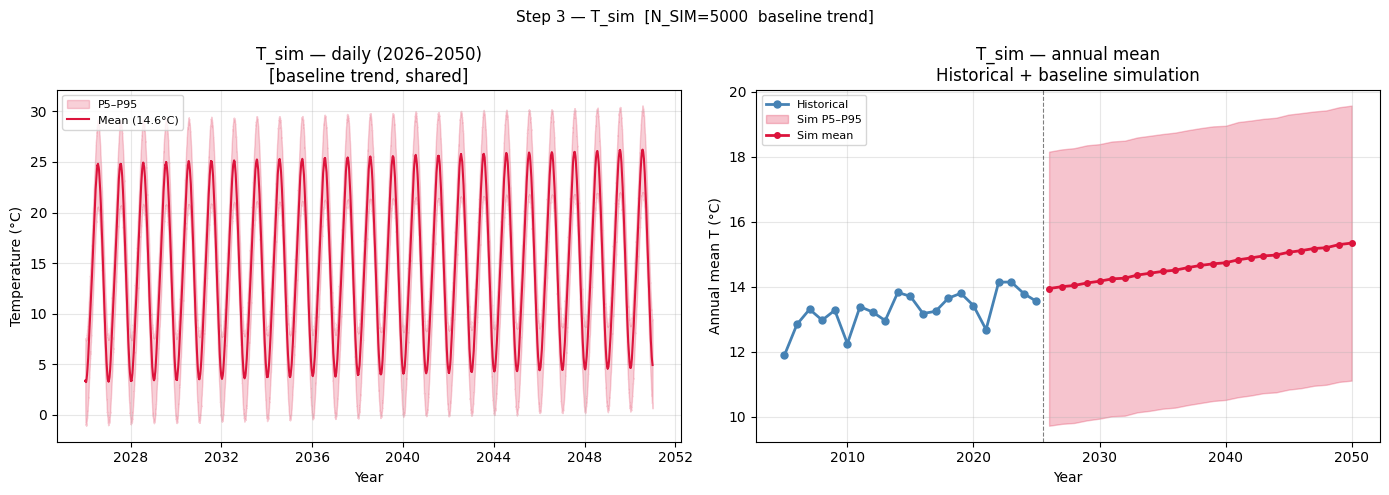

In [12]:
print(f"\n── Step 3: Reconstruct T_sim(t) [shared] ────────────────────────")
 
# D2: vectorised over paths, as Step 5 already is: the AR(2) recursion is
# sequential in TIME but independent across paths, so the outer loop runs over
# t and each statement operates on an (N_SIM,) vector. Identical arithmetic to
# the per-path version, N_DAYS iterations instead of N_SIM x N_DAYS.
T_sim = np.zeros((N_SIM, N_DAYS), dtype=np.float32)   # D6
 
_r1 = np.full(N_SIM, float(temp_ar_init[0]))   # resid(t-1)
_r2 = np.full(N_SIM, float(temp_ar_init[1]))   # resid(t-2)
for t in range(N_DAYS):
    # eps_temp is unit-variance; scale to the fitted innovation sd
    _resid_t = (ar_temp[0] * _r1
                + ar_temp[1] * _r2
                + eps_temp_raw[:, t] * sd_temp_innov)
    T_sim[:, t] = temp_seasonal_sim[t] + _resid_t
    _r2, _r1 = _r1, _resid_t
 
T_flat = T_sim.ravel()
print(f"\n  T_sim stats:")
print(f"    mean={T_flat.mean():.2f}°C  std={T_flat.std():.2f}°C  "
      f"p5={np.percentile(T_flat,5):.1f}°C  p95={np.percentile(T_flat,95):.1f}°C")
for yr in [2026, 2035, 2050]:
    m = (df_cal["year"] == yr).values
    print(f"    {yr} mean: {T_sim[:,m].mean():.2f}°C  "
          f"{'✓' if 10 < T_sim[:,m].mean() < 22 else '✗'}")
 
# fan chart
T_mean = T_sim.mean(axis=0)
T_p5   = np.percentile(T_sim,  5, axis=0)
T_p95  = np.percentile(T_sim, 95, axis=0)
df_T_ann = pd.DataFrame({
    "year": df_cal["year"].values,
    "mean": T_mean, "p5": T_p5, "p95": T_p95
}).groupby("year")[["mean","p5","p95"]].mean()
 
temp_col_hist = next(
    (c for c in ["t2m_mean","t2m_daily","t2m","temp_mean","T_mean"]
     if c in df_temp_hist.columns), None
)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.fill_between(dates_pd, T_p5, T_p95, alpha=0.20, color="crimson", label="P5–P95")
ax.plot(dates_pd, T_mean, color="crimson", lw=1.5, label=f"Mean ({T_mean.mean():.1f}°C)")
ax.set_xlabel("Year"); ax.set_ylabel("Temperature (°C)")
ax.set_title("T_sim — daily (2026–2050)\n[baseline trend, shared]")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8); ax.grid(alpha=0.3)
 
ax = axes[1]
if temp_col_hist:
    df_temp_hist["year_col"] = df_temp_hist["date"].dt.year
    T_hist_ann = df_temp_hist.groupby("year_col")[temp_col_hist].mean()
    ax.plot(T_hist_ann.index, T_hist_ann.values, "o-",
            color="steelblue", lw=2.0, ms=5, label="Historical")
ax.fill_between(df_T_ann.index, df_T_ann["p5"], df_T_ann["p95"],
                alpha=0.25, color="crimson", label="Sim P5–P95")
ax.plot(df_T_ann.index, df_T_ann["mean"], "o-",
        color="crimson", lw=2.0, ms=4, label="Sim mean")
ax.axvline(2025.5, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("Year"); ax.set_ylabel("Annual mean T (°C)")
ax.set_title("T_sim — annual mean\nHistorical + baseline simulation")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
 
plt.suptitle(f"Step 3 — T_sim  [N_SIM={N_SIM}  baseline trend]", fontsize=11)
plt.tight_layout()
plt.show()

> **Takeaway.** The simulated daily temperature band and the historical annual mean sit close together across the shared 2005-2050 span, confirming the AR(2) reconstruction reproduces the fitted trend and seasonal cycle rather than drifting away from the observed record.

### Irradiance paths

Also shared. The ARMA(2,1) runs on the logit-transformed clearness index, which
is then inverted and multiplied by the clear-sky profile.

In [13]:
print(f"\n── Step 4: Reconstruct GHI_sim(t) [shared] ──────────────────────")
 
def invert_logit_to_kt_vec(Y_t, alpha, beta):
    """Invert the rescaled-logit transform back to the clearness index Kt.

    Array form; the recursion below is vectorised over paths (D2)."""
    Xp = 1.0 / (1.0 + np.exp(-Y_t))
    Xt = alpha + beta * Xp
    return np.clip(1.0 - Xt, 0.001, 0.999)
 
 
# Vectorised over paths — see the note in Step 3. The ARMA(2,1) recursion is
# sequential in time and independent across paths.
KT_sim  = np.zeros((N_SIM, N_DAYS), dtype=np.float32)   # D6
GHI_sim = np.zeros((N_SIM, N_DAYS), dtype=np.float32)   # D6
 
_y1 = np.full(N_SIM, float(kt_ytilde_init[0]))   # ytilde(t-1)
_y2 = np.full(N_SIM, float(kt_ytilde_init[1]))   # ytilde(t-2)
_e_prev = np.full(N_SIM, float(kt_eps_init))     # eps(t-1)
for t in range(N_DAYS):
    _eps_t    = eps_kt_raw[:, t]                 # monthly-GMM innovation
    _ytilde_t = (arma_phi[0] * _y1
                 + arma_phi[1] * _y2
                 + _eps_t + arma_theta[0] * _e_prev)
    _kt_t = invert_logit_to_kt_vec(_ytilde_t + Y_bar_sim[t], alpha_kt, beta_kt)
    KT_sim[:, t]  = _kt_t
    GHI_sim[:, t] = _kt_t * ghi_clearsky_sim[t]
    _y2, _y1 = _y1, _ytilde_t
    _e_prev  = _eps_t
 
KT_flat  = KT_sim.ravel()
GHI_flat = GHI_sim.ravel()
print(f"  KT_sim : mean={KT_flat.mean():.4f}  "
      f"p5={np.percentile(KT_flat,5):.4f}  p95={np.percentile(KT_flat,95):.4f}")
print(f"  GHI_sim: mean={GHI_flat.mean():.0f}  "
      f"p5={np.percentile(GHI_flat,5):.0f}  p95={np.percentile(GHI_flat,95):.0f} Wh/m2")


── Step 4: Reconstruct GHI_sim(t) [shared] ──────────────────────


  KT_sim : mean=0.7564  p5=0.2029  p95=0.9990


  GHI_sim: mean=4079  p5=635  p95=7973 Wh/m2


In [14]:
# ── free KT/temp innovations — no longer needed after Step 4 ──────────────
# eps_cr_raw is kept alive: Step 5's CR recursion still reads it.
import gc
del eps_kt_raw, eps_temp_raw
gc.collect()
print("freed eps_kt_raw / eps_temp_raw")

freed eps_kt_raw / eps_temp_raw


### Capture-rate paths

The one variable that differs between penetration scenarios, through the
deterministic mean `mu_CR(pen)`.


── Step 5: Reconstruct CR_sim(t) [per penetration scenario] ─────
  σ² circuit-breaker: σ_cap = 3 × hist max 0.2077 = 0.6232

  Processing: Current Trend (30%)


    done (5000 paths × 9131 days)


    gate: σ²cap 0.0014% (≤0.10%)  resid sd 1.02x hist (≤1.5x)  CR<0 0.0104% (≤1%)
    mean=0.8451  std=0.0763  p5~0.7389  p95~0.9567  (p5/p95 from a 200-pt subsample)
    μ_CR(2050)=0.8036  CR_sim(2050) mean=0.8034

  Processing: PNIEC 2024 (45%)


    done (5000 paths × 9131 days)


    gate: σ²cap 0.0014% (≤0.10%)  resid sd 1.02x hist (≤1.5x)  CR<0 0.0131% (≤1%)
    mean=0.7950  std=0.0917  p5~0.6678  p95~0.9366  (p5/p95 from a 200-pt subsample)
    μ_CR(2050)=0.7234  CR_sim(2050) mean=0.7232

  Processing: ENTSO-E DE (60%)


    done (5000 paths × 9131 days)


    gate: σ²cap 0.0014% (≤0.10%)  resid sd 1.02x hist (≤1.5x)  CR<0 0.0166% (≤1%)
    mean=0.7510  std=0.1091  p5~0.5991  p95~0.9265  (p5/p95 from a 200-pt subsample)
    μ_CR(2050)=0.6538  CR_sim(2050) mean=0.6536


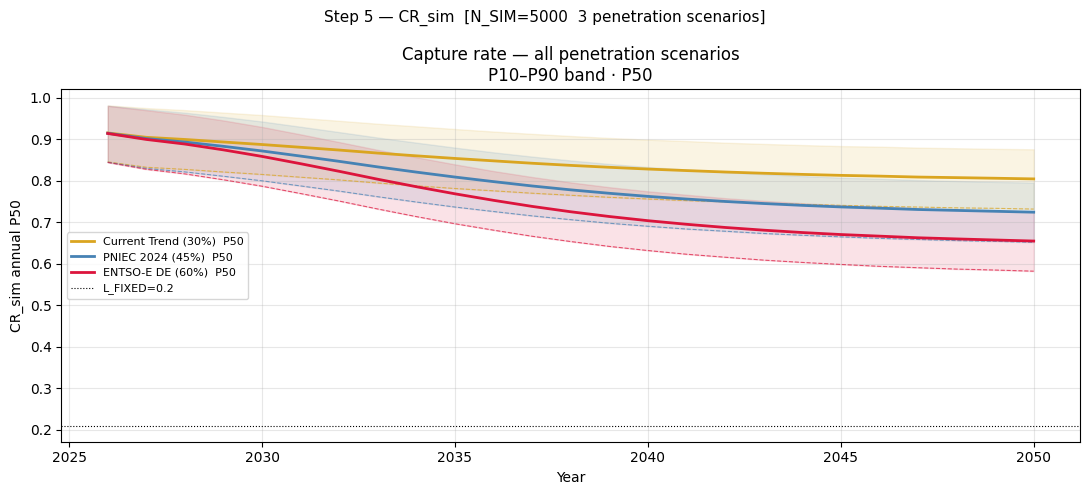

In [15]:
print(f"\n── Step 5: Reconstruct CR_sim(t) [per penetration scenario] ─────")
 

# ── sigma² circuit-breaker ────────────────────────────────────────────────────
# Derived from the historical conditional-volatility path rather than hardcoded.
# This is a CIRCUIT BREAKER, not a modelling choice: with a correctly scaled
# eps_cr it must never bind.  Binding frequency is asserted per scenario.
SIGMA_CAP_MULT  = 3.0
_sigma_hist_max = float(df_cr_hist["sigma_t"].dropna().max())
SIGMA2_CAP      = (SIGMA_CAP_MULT * _sigma_hist_max) ** 2
CAP_HIT_TOL     = 0.001   # max share of (path, day) cells allowed to bind
_resid_std_hist = float(df_cr_hist["CR_resid"].dropna().std())
print(f"  σ² circuit-breaker: σ_cap = {SIGMA_CAP_MULT:.0f} × hist max "
      f"{_sigma_hist_max:.4f} = {np.sqrt(SIGMA2_CAP):.4f}")

CR_sim_scenarios = {}
colors_scen = {
    "current_trend": "goldenrod",
    "pniec":         "steelblue",
    "entso_e":       "crimson",
}
years_unique = sorted(df_cal["year"].unique())
 
for scen_key, mu_CR_arr in mu_CR_scenarios.items():
    label = PEN_LABELS[scen_key]
    print(f"\n  Processing: {label}")
    CR_sim_scen = np.zeros((N_SIM, N_DAYS))
    # Vectorised over all N_SIM paths simultaneously
    cr_buf   = np.tile(cr_resid_init, (N_SIM, 1))  # (N_SIM, 8)
    u_buf    = np.tile(u_s_init,      (N_SIM, 1))  # (N_SIM, 7)
    sig2_vec = np.full(N_SIM, sigma2_init)
    n_cap_hits = 0
    for t in range(N_DAYS):
        sig2_t = (omega_g / 1e4) + alpha_g * u_buf[:, -1]**2 + beta_g * sig2_vec
        n_cap_hits += int(np.count_nonzero(sig2_t > SIGMA2_CAP))
        sig2_t = np.minimum(sig2_t, SIGMA2_CAP)
        u_t    = eps_cr_raw[:, t] * np.sqrt(sig2_t)
        cr_t   = (  phi_s   * cr_buf[:, -1]
                  + Phi_s   * cr_buf[:, -7]
                  - phi_s * Phi_s * cr_buf[:, -8]
                  + theta_q * u_buf[:, -7]
                  + u_t)
        CR_sim_scen[:, t] = mu_CR_arr[t] + cr_t
        cr_buf[:, :-1] = cr_buf[:, 1:]; cr_buf[:, -1] = cr_t
        u_buf[:, :-1]  = u_buf[:, 1:];  u_buf[:, -1]  = u_t
        sig2_vec = sig2_t
    print(f"    done ({N_SIM} paths × {N_DAYS} days)")

    # ── per-scenario sanity gate ──────────────────────────────────────────────
    # The circuit-breaker must be inert and the simulated residual scale must be
    # comparable to history.  Both failed before the eps_cr scaling was fixed.
    _cap_share     = n_cap_hits / (N_SIM * N_DAYS)
    _n_b = _s_b = _s2_b = 0.0
    for _i0 in range(0, N_SIM, 500):
        _blk = CR_sim_scen[_i0:_i0+500] - mu_CR_arr[None, :]
        _n_b += _blk.size
        _s_b += float(_blk.sum())
        _s2_b += float(np.einsum("ij,ij->", _blk, _blk))
    del _blk
    _resid_std_sim = float(np.sqrt(_s2_b/_n_b - (_s_b/_n_b)**2))
    _ratio         = _resid_std_sim / _resid_std_hist
    _neg_share     = float(np.mean(CR_sim_scen < 0))
    print(f"    gate: σ²cap {_cap_share:.4%} (≤{CAP_HIT_TOL:.2%})  "
          f"resid sd {_ratio:.2f}x hist (≤1.5x)  "
          f"CR<0 {_neg_share:.4%} (≤1%)")
    _gate_failures = []
    if _cap_share > CAP_HIT_TOL:
        _gate_failures.append(f"σ² cap bound on {_cap_share:.2%} of cells")
    if not (1/1.5) <= _ratio <= 1.5:
        _gate_failures.append(f"CR residual sd is {_ratio:.2f}x historical")
    if _neg_share > 0.01:
        _gate_failures.append(f"{_neg_share:.2%} of days have CR < 0")
    if _gate_failures:
        _NL = chr(10)
        raise ValueError(f"STOP — scenario {label!r} failed its sanity gate:"
                         + _NL + "    "
                         + (_NL + "    ").join(_gate_failures))
    CR_sim_scenarios[scen_key] = CR_sim_scen
    mu50      = float(mu_CR_arr[df_cal["year"] == 2050].mean())
    cr50_mean = float(CR_sim_scen[:, df_cal["year"].values == 2050].mean())
    # blockwise mean/std (as the sanity gate above) + a random subsample for
    # percentiles — avoids materialising / copying the full 45.6M-element array
    # a second time (np.percentile internally copies its input).
    _n_c = _s_c = _s2_c = 0.0
    for _i0 in range(0, N_SIM, 500):
        _blk = CR_sim_scen[_i0:_i0+500]
        _n_c += _blk.size
        _s_c += float(_blk.sum())
        _s2_c += float(np.einsum("ij,ij->", _blk, _blk))
    _mean_c = _s_c / _n_c
    _std_c  = float(np.sqrt(max(_s2_c/_n_c - _mean_c**2, 0.0)))
    _rng_diag = np.random.default_rng(0)
    _sub = CR_sim_scen[_rng_diag.integers(0, N_SIM, 200),
                       _rng_diag.integers(0, N_DAYS, 200)]
    print(f"    mean={_mean_c:.4f}  std={_std_c:.4f}  "
          f"p5~{np.percentile(_sub,5):.4f}  p95~{np.percentile(_sub,95):.4f}"
          "  (p5/p95 from a 200-pt subsample)")
    print(f"    μ_CR(2050)={mu50:.4f}  CR_sim(2050) mean={cr50_mean:.4f}")
 
# comparison plot
fig, ax = plt.subplots(figsize=(11, 5))
for scen_key, CR_sim_scen in CR_sim_scenarios.items():
    p10_yr = [np.percentile(CR_sim_scen[:, df_cal["year"].values==yr], 10)
               for yr in years_unique]
    p50_yr = [np.percentile(CR_sim_scen[:, df_cal["year"].values==yr], 50)
               for yr in years_unique]
    p90_yr = [np.percentile(CR_sim_scen[:, df_cal["year"].values==yr], 90)
               for yr in years_unique]
    color = colors_scen[scen_key]
    ax.fill_between(years_unique, p10_yr, p90_yr, alpha=0.12, color=color)
    ax.plot(years_unique, p50_yr, color=color, lw=2.0,
            label=f"{PEN_LABELS[scen_key]}  P50")
    ax.plot(years_unique, p10_yr, color=color, lw=0.8, ls="--", alpha=0.7)
ax.axhline(effective_L_cr, color="black", lw=0.8, ls=":", label=f"L_FIXED={L_FIXED}")
ax.set_xlabel("Year"); ax.set_ylabel("CR_sim annual P50")
ax.set_title("Capture rate — all penetration scenarios\nP10–P90 band · P50")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle(f"Step 5 — CR_sim  [N_SIM={N_SIM}  3 penetration scenarios]", fontsize=11)
plt.tight_layout()
plt.show()
 

> **Takeaway.** The three penetration scenarios separate cleanly by 2050, with entso_e sitting below pniec and current_trend, in the same order as their capture-rate decline -- confirming the deterministic mean mu_CR is driving the simulated paths apart as intended, not just adding noise around one shared trend.

In [16]:
# ── free the raw CR innovations — Step 5 was the last consumer ──────────────
del eps_cr_raw
gc.collect()
print("freed eps_cr_raw")

freed eps_cr_raw


### Export

In [17]:
print(f"\n── Step 6: Save physical variables ─────────────────────────────")
 

PATHS_PER_BLOCK = 200

# D7: calendar columns are attached by TILING, not merging: each block of
# N_DAYS rows carries dates_sim in identical order for every path, so tiling is
# exactly the left-merge on `date` without the 45.6M-element join indexers.
# Tiles are built per block rather than once for all N_SIM paths, which would
# hold four full-length arrays resident across all three scenarios.
_cal = df_cal.sort_values("date").reset_index(drop=True)
assert np.array_equal(pd.to_datetime(_cal["date"]).values,
                      pd.to_datetime(dates_sim).values), \
    "df_cal dates do not match dates_sim - tiling would misalign the calendar"
_dates_ns = pd.to_datetime(dates_sim)
 
saved_files = []
 
for scen_key, CR_sim_scen in CR_sim_scenarios.items():
    label    = PEN_LABELS[scen_key]
    pen_arr  = pen_arrays[scen_key]
    mu_arr   = mu_CR_scenarios[scen_key]
    out_file = output_path / f"mc_physical_variables_{scen_key}.parquet"
 
    # Streamed write: one row group per block of paths. Peak memory is a
    # single block (~180 MB) rather than a full 45.6M-row frame per scenario.
    _writer = None
    _rows = 0
    for _i0 in range(0, N_SIM, PATHS_PER_BLOCK):
        _i1 = min(_i0 + PATHS_PER_BLOCK, N_SIM)
        _n = _i1 - _i0
        _d = pd.DataFrame({
            "sim_id":  np.repeat(np.arange(_i0, _i1, dtype=np.int32), N_DAYS),
            "date":    np.tile(_dates_ns, _n),
            "T_sim":   T_sim[_i0:_i1].ravel().astype(np.float32),
            "GHI_sim": GHI_sim[_i0:_i1].ravel().astype(np.float32),
            "KT_sim":  KT_sim[_i0:_i1].ravel().astype(np.float32),
            "CR_sim":  CR_sim_scen[_i0:_i1].ravel().astype(np.float32),
        })
        for _c in ["year", "month", "doy", "ghi_clearsky"]:
            _d[_c] = np.tile(_cal[_c].values, _n)
        _d["pen_scenario"]      = np.tile(pen_arr.astype(np.float32), _n)
        _d["mu_CR_sim"]         = np.tile(mu_arr.astype(np.float32), _n)
        # Constant per file, so store it dictionary-encoded rather than as
        # 45.6M copies of the same short string.
        _d["pen_scenario_name"] = pd.Categorical(
            [scen_key] * len(_d), categories=list(PEN_SCENARIOS))
        _tbl = pa.Table.from_pandas(_d, preserve_index=False)
        if _writer is None:
            _writer = pq.ParquetWriter(out_file, _tbl.schema, compression="snappy")
        _writer.write_table(_tbl)
        _rows += _tbl.num_rows
        del _d, _tbl
        gc.collect()
    _writer.close()

    # -- post-write read-back (the gap this notebook used to have) -------------
    # The artifact, not the in-memory array, is what four downstream notebooks
    # consume. A truncated or mis-ordered write would otherwise surface as a
    # reshape error three notebooks later, or worse, not at all.
    _pf_chk = pq.ParquetFile(out_file)
    assert _pf_chk.metadata.num_rows == N_SIM * N_DAYS, (
        f"STOP -- {out_file.name} holds {_pf_chk.metadata.num_rows:,} rows, "
        f"expected N_SIM x N_DAYS = {N_SIM} x {N_DAYS} = {N_SIM*N_DAYS:,}."
    )
    _first = _pf_chk.read_row_group(0, columns=["sim_id", "date", "CR_sim"])
    _sid = _first.column("sim_id").to_numpy()
    assert _sid[0] == 0 and np.array_equal(_sid[:N_DAYS], np.zeros(N_DAYS, _sid.dtype)), (
        f"STOP -- {out_file.name} does not start with a complete path 0; the "
        f"file is not sim-major and cannot be reshaped downstream."
    )
    assert np.allclose(_first.column("CR_sim").to_numpy()[:N_DAYS],
                       CR_sim_scen[0].astype(np.float32), atol=1e-6), (
        f"STOP -- CR_sim read back from {out_file.name} does not match the "
        f"array just written."
    )
    del _pf_chk, _first, _sid

    file_mb = out_file.stat().st_size / 1e6
    saved_files.append(str(out_file))

    print(f"  [{scen_key}] {label}")
    print(f"    File : {out_file.name}  ({file_mb:.1f} MB)")
    print(f"    Rows : {_rows:,}")
    print(f"    CR_sim mean : {CR_sim_scen.mean():.4f}")
    print(f"    T_sim  mean : {T_sim.mean():.2f}°C")
    print(f"    GHI_sim mean: {GHI_sim.mean():.0f} Wh/m2")
    gc.collect()
 
print(f"\n── Reconstruction complete ───────────────────────────────────────")
print(f"  Saved {len(saved_files)} parquet files:")
for f in saved_files:
    print(f"    {Path(f).name}")
print(f"\n  T_sim and GHI_sim are SHARED across all penetration scenarios.")
print(f"  CR_sim differs per scenario due to μ_CR(pen_scenario).")


── Step 6: Save physical variables ─────────────────────────────


  [current_trend] Current Trend (30%)
    File : mc_physical_variables_current_trend.parquet  (1110.1 MB)
    Rows : 45,655,000
    CR_sim mean : 0.8451
    T_sim  mean : 14.64°C
    GHI_sim mean: 4079 Wh/m2


  [pniec] PNIEC 2024 (45%)
    File : mc_physical_variables_pniec.parquet  (1110.3 MB)
    Rows : 45,655,000
    CR_sim mean : 0.7950
    T_sim  mean : 14.64°C
    GHI_sim mean: 4079 Wh/m2


  [entso_e] ENTSO-E DE (60%)
    File : mc_physical_variables_entso_e.parquet  (1110.4 MB)
    Rows : 45,655,000
    CR_sim mean : 0.7510
    T_sim  mean : 14.64°C


    GHI_sim mean: 4079 Wh/m2

── Reconstruction complete ───────────────────────────────────────
  Saved 3 parquet files:
    mc_physical_variables_current_trend.parquet
    mc_physical_variables_pniec.parquet
    mc_physical_variables_entso_e.parquet

  T_sim and GHI_sim are SHARED across all penetration scenarios.
  CR_sim differs per scenario due to μ_CR(pen_scenario).


> **Read-back.** Each scenario file is verified on disk for row count, sim-major ordering and content before the notebook moves on, so a truncated or mis-ordered write is caught here rather than downstream, where three notebooks read these files without re-checking them.

### Scenario diagnostics

  Baseline (~SSP2-4.5)   T(2050) annual-mean P50 =  15.35°C   Δ vs baseline = +0.00°C


  SSP1-2.6               T(2050) annual-mean P50 =  14.74°C   Δ vs baseline = -0.61°C


  SSP5-8.5               T(2050) annual-mean P50 =  15.99°C   Δ vs baseline = +0.64°C


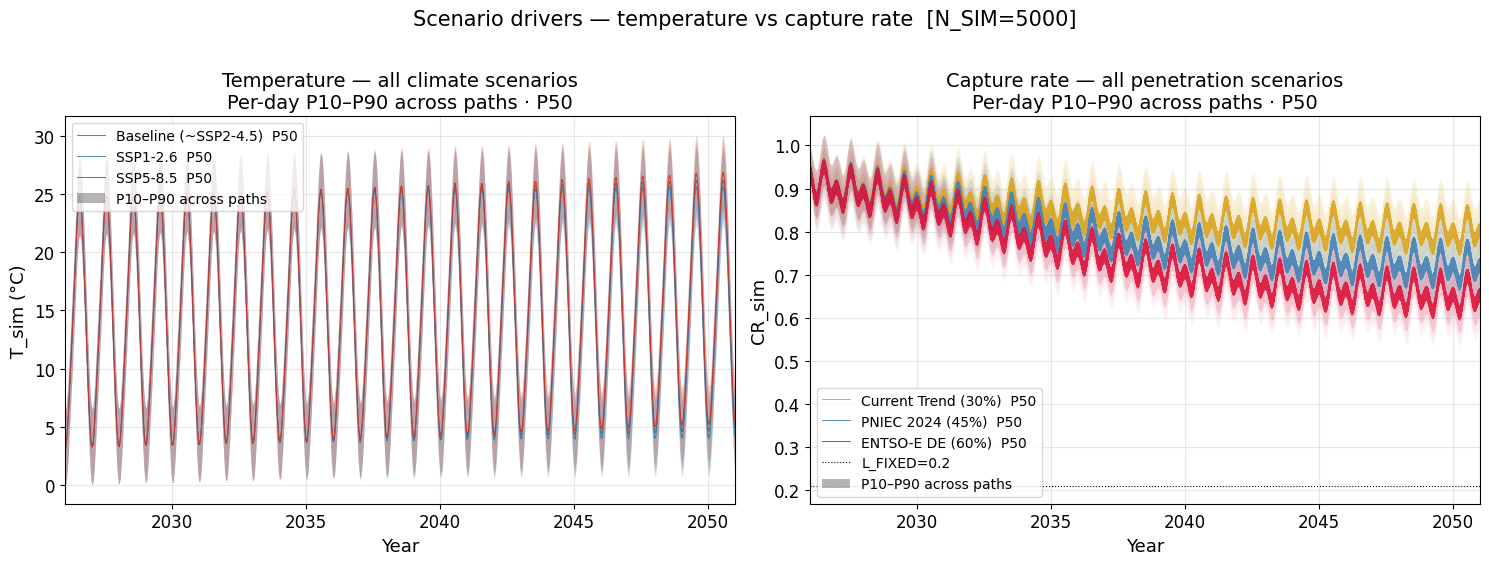

In [18]:
# ── Temperature scenarios vs capture-rate scenarios, side by side ──────
#
# Same construction as the Step 5 CR comparison plot, applied to temperature.
#
# T_sim is reconstructed here on the BASELINE trend only, so the three SSP
# paths are formed by adding the scenario deltas from
# df_temperature_scenarios.parquet — the same operation the Revenue Index
# notebook performs. delta_baseline is identically zero.
#
# Bands are PER CALENDAR DAY: for each of the 9131 dates, percentiles are taken
# ACROSS THE 1000 PATHS. The band therefore follows the seasonal cycle instead
# of collapsing it — a January band sits low and a July band sits high, which a
# per-year band cannot show. Read it as "on this date, where do 80% of the
# simulated outcomes fall".
#
# This is NOT the Step 5 CR construction, which pools all (path, day) cells in a
# year into one number. That pooled band mixes seasonal position with path
# uncertainty; this one separates them. The CR panel here consequently differs
# from the Step 5 figure — deliberately.

from matplotlib.patches import Patch

df_temp_scen = pd.read_parquet(data_cleaned / "df_temperature_scenarios.parquet")
df_temp_scen["date"] = pd.to_datetime(df_temp_scen["date"])

_ts = (df_temp_scen.set_index("date")
                   .reindex(pd.to_datetime(dates_sim)))
assert _ts["delta_ssp126"].notna().all(), "temperature scenarios do not cover the simulation calendar"

TEMP_DELTAS = {
    "baseline": np.zeros(N_DAYS),
    "ssp126":   _ts["delta_ssp126"].values,
    "ssp585":   _ts["delta_ssp585"].values,
}
TEMP_LABELS = {
    "baseline": "Baseline (~SSP2-4.5)",
    "ssp126":   "SSP1-2.6",
    "ssp585":   "SSP5-8.5",
}
# blue → grey → red reads as cool → warm; deliberately not the CR palette,
# because the two panels encode different factors and share no legend.
colors_temp = {
    "baseline": "dimgray",
    "ssp126":   "#2c7fb8",
    "ssp585":   "#d7301f",
}

_yr_arr = df_cal["year"].values

_dec_yr = df_cal["decimal_year"].values

def _daily_bands(mat, deltas=None):
    """P10 / P50 / P90 across paths, separately for each calendar day."""
    p10, p50, p90 = np.percentile(mat, [10, 50, 90], axis=0)
    if deltas is not None:
        p10, p50, p90 = p10 + deltas, p50 + deltas, p90 + deltas
    return p10, p50, p90

def _to_annual(v):
    """Collapse a daily series to its annual means, for the printed summary."""
    return np.array([v[_yr_arr == _y].mean() for _y in years_unique])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── left: temperature scenarios ──────────────────────────────────
ax = axes[0]
_base_p50_ann = _to_annual(_daily_bands(T_sim, TEMP_DELTAS["baseline"])[1])
for _k, _delta in TEMP_DELTAS.items():
    _p10, _p50, _p90 = _daily_bands(T_sim, _delta)
    _c = colors_temp[_k]
    ax.fill_between(_dec_yr, _p10, _p90, alpha=0.24, color=_c, lw=0)
    ax.plot(_dec_yr, _p50, color=_c, lw=0.7, alpha=0.9,
            label=f"{TEMP_LABELS[_k]}  P50")
    _ann = _to_annual(_p50)
    print(f"  {TEMP_LABELS[_k]:<22} T(2050) annual-mean P50 = {_ann[-1]:6.2f}°C"
          f"   Δ vs baseline = {_ann[-1] - _base_p50_ann[-1]:+.2f}°C")

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("T_sim (°C)", fontsize=13)
ax.set_title("Temperature — all climate scenarios\nPer-day P10–P90 across paths · P50", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.set_xlim(_dec_yr[0], _dec_yr[-1])
# the shaded band gets its own legend entry — a neutral swatch, since the
# band colour repeats per scenario and is already keyed by the P50 line.
_h, _l = ax.get_legend_handles_labels()
_h.append(Patch(facecolor="0.35", alpha=0.45, linewidth=0))
_l.append("P10–P90 across paths")
ax.legend(_h, _l, fontsize=10, loc="upper left")
ax.grid(alpha=0.3)

# ── right: capture rate scenarios (unchanged from Step 5) ───────────────
ax = axes[1]
for _k, _cr in CR_sim_scenarios.items():
    _p10, _p50, _p90 = _daily_bands(_cr)
    _c = colors_scen[_k]
    ax.fill_between(_dec_yr, _p10, _p90, alpha=0.24, color=_c, lw=0)
    ax.plot(_dec_yr, _p50, color=_c, lw=0.7, alpha=0.9,
            label=f"{PEN_LABELS[_k]}  P50")
ax.axhline(effective_L_cr, color="black", lw=0.8, ls=":", label=f"L_FIXED={L_FIXED}")
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("CR_sim", fontsize=13)
ax.set_title("Capture rate — all penetration scenarios\nPer-day P10–P90 across paths · P50", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.set_xlim(_dec_yr[0], _dec_yr[-1])
# the shaded band gets its own legend entry — a neutral swatch, since the
# band colour repeats per scenario and is already keyed by the P50 line.
_h, _l = ax.get_legend_handles_labels()
_h.append(Patch(facecolor="0.35", alpha=0.45, linewidth=0))
_l.append("P10–P90 across paths")
ax.legend(_h, _l, fontsize=10, loc="lower left")
ax.grid(alpha=0.3)

plt.suptitle(f"Scenario drivers — temperature vs capture rate  [N_SIM={N_SIM}]",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

> **Takeaway.** The SSP temperature scenarios diverge visibly by 2050 while sharing the same 2026 starting point, and the three penetration scenarios' capture-rate bands separate similarly -- confirming both scenario axes drive the underlying paths as intended before they are combined downstream.

  zoom window: 2040-2043  (1,461 days)


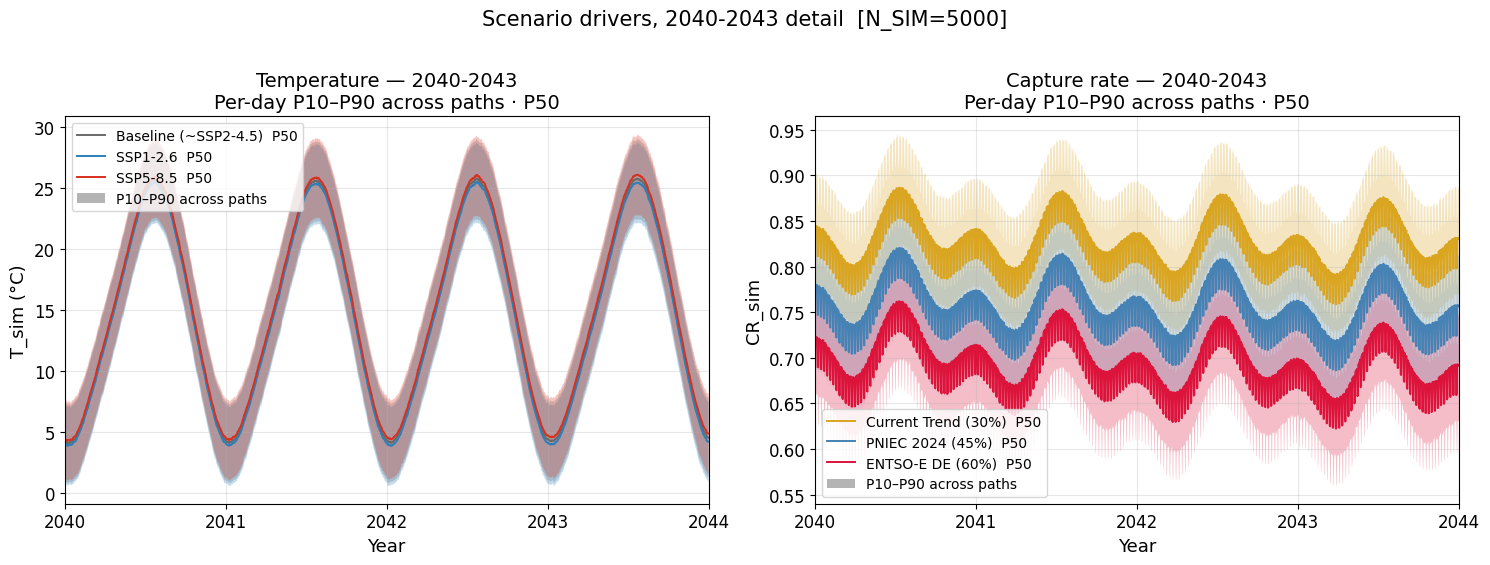

  T  (°C) P10-P90 width — Jan 6.515   Jul 6.524   ratio 1.00x


  CR      P10-P90 width — Jan 0.119   Jul 0.120   ratio 1.01x


In [19]:
# ── Same figure, zoomed to 2040-2043 — the band at readable resolution ──
#
# The full-horizon version compresses 25 seasonal cycles into a few hundred
# pixels, so the per-day band reads as texture. Four years is enough to see the
# band actually breathe with the season while still showing the trend.
# No individual paths here — the point of the zoom is the BAND, and daily
# traces sit on top of it and hide the edge.
#
# Reuses TEMP_DELTAS / colors_temp / _daily_bands from the cell
# above. Arrays are SLICED to the window before the percentiles are taken, so
# this is cheaper than the full-horizon figure, not more expensive.

from matplotlib.patches import Patch

ZOOM_FROM, ZOOM_TO = 2040, 2043          # inclusive, calendar years

_zm  = (_yr_arr >= ZOOM_FROM) & (_yr_arr <= ZOOM_TO)
_zx  = _dec_yr[_zm]
_zT  = T_sim[:, _zm]
print(f"  zoom window: {ZOOM_FROM}-{ZOOM_TO}  ({_zm.sum():,} days)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── left: temperature ────────────────────────────────────────────
ax = axes[0]
for _k, _delta in TEMP_DELTAS.items():
    _p10, _p50, _p90 = _daily_bands(_zT, _delta[_zm])
    _c = colors_temp[_k]
    ax.fill_between(_zx, _p10, _p90, alpha=0.28, color=_c, lw=0)
    ax.plot(_zx, _p50, color=_c, lw=1.4, label=f"{TEMP_LABELS[_k]}  P50")
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("T_sim (°C)", fontsize=13)
ax.set_title(f"Temperature — {ZOOM_FROM}-{ZOOM_TO}\nPer-day P10–P90 across paths · P50",
             fontsize=14)
ax.set_xlim(_zx[0], _zx[-1])
ax.set_xticks(range(ZOOM_FROM, ZOOM_TO + 2))
ax.tick_params(axis="both", labelsize=12)
# the shaded band gets its own legend entry — a neutral swatch, since the
# band colour repeats per scenario and is already keyed by the P50 line.
_h, _l = ax.get_legend_handles_labels()
_h.append(Patch(facecolor="0.35", alpha=0.45, linewidth=0))
_l.append("P10–P90 across paths")
ax.legend(_h, _l, fontsize=10, loc="upper left")
ax.grid(alpha=0.3)

# ── right: capture rate ──────────────────────────────────────────
ax = axes[1]
for _k, _cr in CR_sim_scenarios.items():
    _p10, _p50, _p90 = _daily_bands(_cr[:, _zm])
    _c = colors_scen[_k]
    ax.fill_between(_zx, _p10, _p90, alpha=0.28, color=_c, lw=0)
    ax.plot(_zx, _p50, color=_c, lw=1.4, label=f"{PEN_LABELS[_k]}  P50")
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("CR_sim", fontsize=13)
ax.set_title(f"Capture rate — {ZOOM_FROM}-{ZOOM_TO}\nPer-day P10–P90 across paths · P50",
             fontsize=14)
ax.set_xlim(_zx[0], _zx[-1])
ax.set_xticks(range(ZOOM_FROM, ZOOM_TO + 2))
ax.tick_params(axis="both", labelsize=12)
# the shaded band gets its own legend entry — a neutral swatch, since the
# band colour repeats per scenario and is already keyed by the P50 line.
_h, _l = ax.get_legend_handles_labels()
_h.append(Patch(facecolor="0.35", alpha=0.45, linewidth=0))
_l.append("P10–P90 across paths")
ax.legend(_h, _l, fontsize=10, loc="lower left")
ax.grid(alpha=0.3)

plt.suptitle(f"Scenario drivers, {ZOOM_FROM}-{ZOOM_TO} detail  [N_SIM={N_SIM}]",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# band width through the season — the number the zoom is meant to expose
for _lbl, _mat, _dl in [("T  (°C)", _zT, TEMP_DELTAS["baseline"][_zm]),
                        ("CR     ", CR_sim_scenarios["current_trend"][:, _zm], None)]:
    _p10, _p50, _p90 = _daily_bands(_mat, _dl)
    _w = _p90 - _p10
    _mo = df_cal["month"].values[_zm] if "month" in df_cal.columns else None
    if _mo is not None:
        _jan = _w[_mo == 1].mean(); _jul = _w[_mo == 7].mean()
        print(f"  {_lbl} P10-P90 width — Jan {_jan:.3f}   Jul {_jul:.3f}"
              f"   ratio {_jul/_jan:.2f}x")

> **Takeaway.** Zoomed to four years, the per-day P10-P90 band visibly widens in summer for both series -- the printed Jan/Jul width ratio quantifies this seasonal breathing, which the full-horizon view above compresses into an almost-constant-looking band.

## Conclusion & Handoff

- Three physical variables reconstructed over 2026-2050 for 5,000 common-random-
  number paths (D1, D2), written as one parquet per penetration scenario.
- `T_sim` and `GHI_sim` are identical across the three files by construction;
  only `CR_sim` and the `mu_CR_sim` / `pen_scenario` columns differ.
- Every file is verified on disk after writing: row count, sim-major ordering
  and content.

**Next notebooks can rely on:**
`Data/Simulated/mc_physical_variables_{current_trend,pniec,entso_e}.parquet` —
long format `(sim_id, date, T_sim, GHI_sim, KT_sim, CR_sim, year, month, doy,
ghi_clearsky, pen_scenario, mu_CR_sim, pen_scenario_name)`, sim-major, float32,
row groups of 200 paths. Read by `04_revenue_index_scenarios.ipynb`, which
applies the SSP temperature deltas, and by `05_hedge_contract.ipynb`.